In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np

In [4]:
# Needed Columns for the Hypothesis testing
data_needed = ["Order Date", "Category", "Revenue", "Shipping Address State", "tavg"]

transactions_temp = pd.read_csv("./Data/data_combined.csv", usecols=data_needed)
transactions_temp["Order Date"] = pd.to_datetime(transactions_temp["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually

In [5]:
transactions_temp = transactions_temp[~transactions_temp["Shipping Address State"].isin(["AK", "HI", "PR", "DC", "I did not reside in the United States"])] # Remove Shipping addresses without temperature information

transactions_temp  = transactions_temp[(transactions_temp['Order Date'] < '2024-01-01')] # Remove transactions from 2024 (we only have one transaction + temperature might be inaccurate)

In [6]:
Fashion = [
    "ACCESSORY", "ADULT_COSTUME", "APPAREL", "APPAREL_BELT", "APPAREL_GLOVES",
    "APPAREL_HEAD_NECK_COVERING", "APPAREL_PIN", "APPENDAGE_WARMER", "APRON",
    "ARM_SLEEVE", "Apparel", "BABY_JUMPER_WALKER", "BELTS", "BLAZER",
    "BLUE_LIGHT_BLOCKING_EYEGLASSES", "BODYSTOCKING", "BOOT", "BRA", "BRACELET",
    "BRA_UNDERWEAR_SET", "CHOLI", "COAT", "COORDINATED_OUTFIT", "CORRECTIVE_EYEGLASSES",
    "CORSET", "DRESS", "DUPATTA", "EARMUFF", "EARRING", "ETHNIC_WEAR",
    "FASHIONEARRING", "FASHIONNECKLACEBRACELETANKLET", "FASHIONOTHER", "FASHIONRING",
    "FASHION_JEWELRY", "FINEEARRING", "FINENECKLACEBRACELETANKLET", "FINERING",
    "FOOTWEAR", "GUILD_APPAREL", "GUILD_JEWELRY", "GUILD_SHOES", "HAT", "HOSIERY",
    "JEWELRY", "JEWELRY_SET", "KIMONO", "KURTA", "LEG_SLEEVE", "LEOTARD",
    "MOISTURIZING_SOCK_GLOVE", "NECKLACE", "NECKTIE", "NIGHTGOWN_NIGHTSHIRT",
    "ORCA_SHIRT", "OUTERWEAR", "OVERALLS", "PAJAMAS", "PANTS", "PIERCING_JEWELRY",
    "ROBE", "SANDAL", "SAREE", "SHIRT", "SHOES", "SHORTS", "SKIRT", "SLEEPWEAR",
    "SLIPPER", "SNOWSHOE", "SNOWSUIT", "SNOW_PANT", "SOCK", "SOCKSHOSIERY", "SUIT",
    "SUNGLASSES", "SUSPENDER", "SWEATER", "SWEATSHIRT", "SWIMWEAR", "SWIM_CAP",
    "TIGHTS", "TRACK_SUIT", "UNDERPANTS", "UNDERWEAR", "UNDERGARMENT_SLIP",
    "UNDERGARMENT_THIGH_SLIMMER", "UNION_SUIT", "VEST", "WATCH", "WATCHES", "WATCH_BAND"
]


Groceries = [
   "ALCOHOLIC_BEVERAGE", "BABY_FOOD", "BABY_FORMULA", "BAKING_CHOCOLATE", "BEER",
   "BEVERAGE", "BREAD", "BREAKFAST_CEREAL", "CAKE", "CANDY", "CEREAL",
   "CHOCOLATE_CANDY", "COFFEE", "CONDIMENT", "COOKIE", "CRACKER", "CULINARY_SALT",
   "DAIRY_BASED_BUTTER", "DAIRY_BASED_CHEESE", "DAIRY_BASED_CREAM",
   "DAIRY_BASED_DRINK", "DAIRY_BASED_ICE_CREAM", "DAIRY_BASED_PUDDING",
   "DAIRY_BASED_YOGURT", "DONUT", "DRINK_FLAVORED", "EDIBLE_OIL_VEGETABLE",
   "FLOUR", "FRUIT", "FRUIT_SNACK", "FUDGE", "GOURMET_FOOD", "GROCERY", "Grocery",
   "HEALTH_FOOD", "HONEY", "JERKY", "JUICE_AND_JUICE_DRINK", "LEGUME",
   "MEAL_REPLACEMENT_BEVERAGE", "MEAT_ALTERNATIVE", "MILK_SUBSTITUTE",
   "NON_DAIRY_CHEESE", "NON_DAIRY_CREAM", "NON_DAIRY_ICE_CREAM",
   "NON_DAIRY_PUDDING", "NON_DAIRY_YOGURT", "NOODLE", "NUTS", "NUT_AND_SEED",
   "NUT_BUTTER", "OLIVE", "PACKAGED_SOUP_AND_STEW", "PASTRY", "POPCORN",
   "PRETZEL", "PROTEIN_DRINK", "PROTEIN_SUPPLEMENT_POWDER", "PUFFED_SNACK",
   "RICE_MIX", "RICE_WINE", "SALAD_DRESSING", "SEAFOOD", "SEASONING",
   "SNACK_CHIP_AND_CRISP", "SNACK_FOOD", "SNACK_FOOD_BAR", "SNACK_MIX",
   "SPORTS_DRINK", "SUGAR", "SUGAR_CANDY", "SUGAR_SUBSTITUTE", "SYRUP", "TEA",
   "TOFU", "VEGETABLE", "VEGETARIAN_EGG_SUBSTITUTE", "WATER"
]

In [7]:
mask_fashion = transactions_temp["Category"].isin(Fashion)
Fashion_transactions = transactions_temp[mask_fashion]
Fashion_transactions = Fashion_transactions.sort_values(["Order Date"]).copy() # .copy() to create new dataframe in memory and not a pd view


mask_groceries = transactions_temp["Category"].isin(Groceries)
Grocerie_transactions = transactions_temp[mask_groceries]
Grocerie_transactions = Grocerie_transactions.sort_values(["Order Date"]).copy()

In [ ]:
Grocerie_transactions = Grocerie_transactions.sort_values("Order Date", ascending=True)

Grocerie_transactions_grouped = Grocerie_transactions.groupby(["Order Date", "Shipping Address State"]).agg({"Revenue": "sum", "tavg":"first"})

Grocerie_transactions_grouped.reset_index(["Order Date", "Shipping Address State"], inplace=True)

### End preprocessing

In [34]:
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):
    maxlag = 12    
    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

In [74]:
# List of states
states_list = Grocerie_transactions_grouped["Shipping Address State"].unique()

# Creating Filtered dataframe for Granger test
df_granger_grocerie = Grocerie_transactions_grouped[["Order Date", "Revenue", "tavg", "Shipping Address State"]]
df_granger_grocerie = df_granger_grocerie.set_index("Order Date")


#### First order diff for Revenue

In [75]:
state_p_values = {}
#states_list = ["FL"]
for i in range(len(states_list)): 
    try: 
        df_one_state = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin([states_list[i]])].copy()

    # Fist order Diff for Revenue
    #first_order_diff = [0]

    #for i in range(1,len(df_one_state)): 
    #    first_order_diff.append(df_one_state["Revenue"][i] - df_one_state["Revenue"][i-1])

    #df_one_state["first_order_diff"] = first_order_diff

    # Remove Seasonality from Temp
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)

        #df_one_state = df_one_state.iloc[12*30:, ].copy()

        df_one_state["Revenue_SMA30"] = df_one_state["Revenue"].rolling(30).mean().round(2)

        df_one_state["Temp_SMA30"] = df_one_state["Temp_No_Season"].rolling(30).mean().round(2)

        df_granger_groceries= df_one_state.iloc[365 + 30:, ].copy()

        granger_matrix = grangers_causation_matrix(df_granger_groceries ,variables=["Revenue_SMA30", "Temp_SMA30"])

        p_value = granger_matrix.iloc[0, 1]
        state_p_values[states_list[i]] = p_value

        print(f"For the state {states_list[i]} temperature as a predictor has a p-value of: {p_value}")
    except: 
        print(f"Error for state {states_list[i]}")
    


For the state CA temperature as a predictor has a p-value of: 0.5955
For the state FL temperature as a predictor has a p-value of: 0.7896
For the state IL temperature as a predictor has a p-value of: 0.1279
For the state IN temperature as a predictor has a p-value of: 0.5927
For the state KY temperature as a predictor has a p-value of: 0.1371
For the state MI temperature as a predictor has a p-value of: 0.1733
For the state MN temperature as a predictor has a p-value of: 0.3136
Error for state NM
For the state NV temperature as a predictor has a p-value of: 0.0202
For the state NY temperature as a predictor has a p-value of: 0.1379
For the state OH temperature as a predictor has a p-value of: 0.0593
For the state OR temperature as a predictor has a p-value of: 0.3444
For the state TX temperature as a predictor has a p-value of: 0.0203
For the state VA temperature as a predictor has a p-value of: 0.2128
For the state WA temperature as a predictor has a p-value of: 0.0002
For the state A

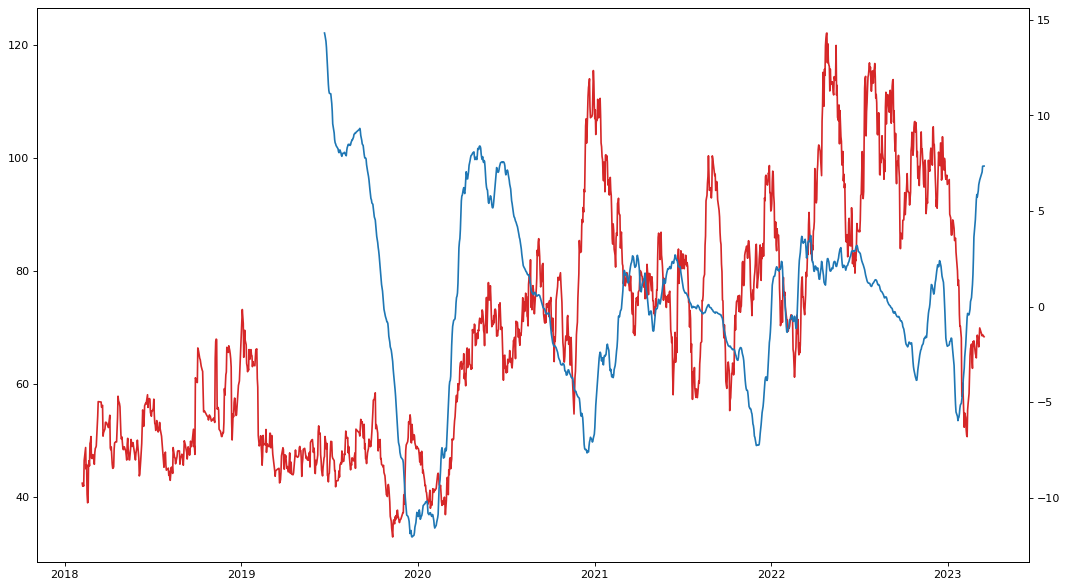

In [73]:
#CA_only = df_granger_grocerie[df_granger_grocerie["Shipping Address State"].isin(["CA"])].copy()
df_one_state["Revenue_SMA30"] = df_one_state["Revenue"].rolling(30).mean().round(2)
df_granger_groceries_plot = df_one_state.reset_index()
# Plotting
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(df_granger_groceries_plot["Order Date"],
            df_granger_groceries_plot["Revenue_SMA30"],
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(df_granger_groceries_plot["Order Date"],
         df_granger_groceries_plot["Temp_SMA30"],
         color="tab:blue")

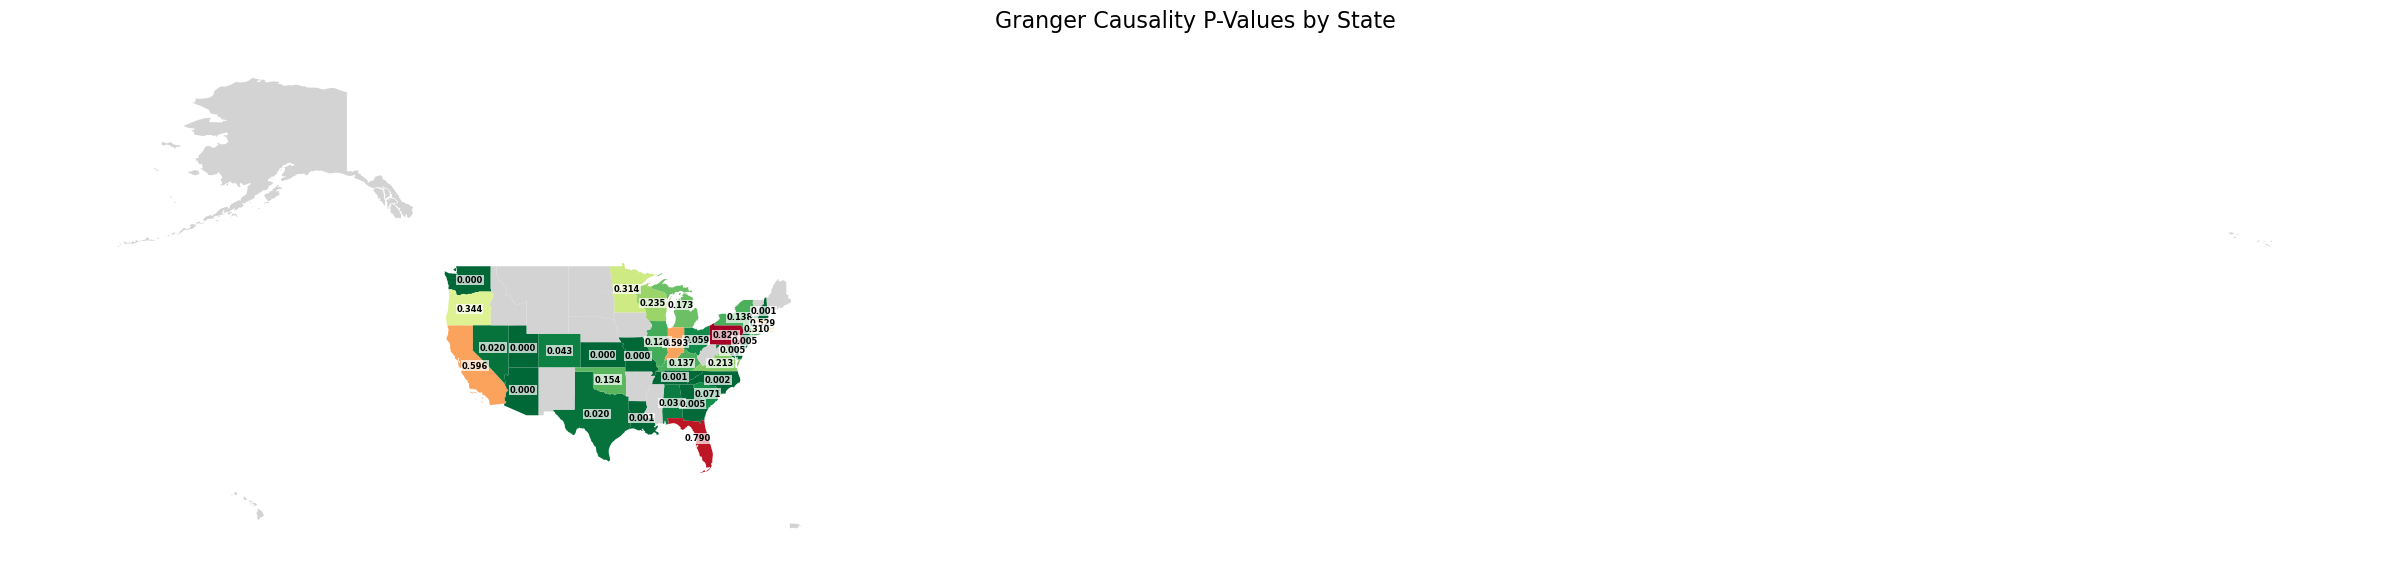

In [71]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert p-values to DataFrame
p_value_df = pd.DataFrame.from_dict(state_p_values, orient='index', columns=['p_value'])
p_value_df.index.name = 'state'

# Load US states shapefile
usa = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip')

# Convert state codes
usa['state'] = usa['STUSPS']

# Merge the p-values with the geographic data
usa = usa.merge(p_value_df, on='state', how='left')

# Create figure and axes with larger size
fig = plt.figure(figsize=(24, 14))
ax = fig.add_subplot(111)

# Create custom colormap from green to red
cmap = plt.cm.RdYlGn_r

# Plot the map
usa.plot(column='p_value',
         cmap=cmap,
         ax=ax,
         legend=False,
         missing_kwds={'color': 'lightgrey'})

# Add p-values as text in each state 
for idx, row in usa.iterrows():
    if not pd.isna(row['p_value']):
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, 
                f'{row["p_value"]:.3f}',  # Show 3 decimal places
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=6,  # Reduced font size
                fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))  # Reduced padding

plt.title('Granger Causality P-Values by State', fontsize=16, pad=20)
ax.axis('off')

# Adjust layout to use full screen width
plt.tight_layout()

plt.show()